Title

To Develop an Integrated Artificial Intelligence Workflow for Natural Product Drug Discovery — A Complete Case Study Combining Predicted Biological Activity, Drug-Likeness, and Synthetic Accessibility to Identify and Optimize Multiple Lead Candidates Against an Anti-Inflammatory Target

Object

To develop an integrated, end-to-end AI-driven drug discovery pipeline for natural products — demonstrating that real pharmaceutical decision-making never relies on a single number, but on balancing predicted biological activity against drug-likeness and practical synthesizability simultaneously.

Objectives
To retrieve a real, large-scale natural product structure library from a public open-access database.
To train a QSAR model on real, experimentally measured bioactivity data for a specific inflammatory drug target.
To virtually screen the entire natural product library and identify multiple promising lead candidates, not a single one.
To generate a systematic set of structurally modified analogs across all identified leads.
To evaluate every candidate on three independent, genuinely calculated criteria: predicted biological activity, drug-likeness, and synthetic accessibility.
To combine these three criteria into one transparent, weighted composite ranking, reflecting how real lead selection decisions are actually made.
To build a deployment tool applying this complete multi-criteria pipeline to any compound a student provides.
Expected Outcomes
Understand why real drug discovery decisions are never based on predicted potency alone — a highly active compound that is impossible to synthesize, or a highly synthesizable compound with poor drug-likeness, is not a viable candidate.
Trace how multiple independently-trained AI/ML techniques (data retrieval, QSAR modelling, virtual screening, multi-property scoring) combine into a single coherent, real pharmaceutical decision-making pipeline.
Interpret a composite, weighted, multi-criteria ranking, and understand why the relative weighting of different criteria is an explicit, adjustable scientific choice, not an arbitrary black box.
Independently apply this same three-criteria evaluation framework to any compound of personal or research interest.

In [1]:
# Block 1: Install libraries and retrieve natural product structures

!pip install rdkit pandas numpy matplotlib scikit-learn chembl_webresource_client -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdFingerprintGenerator, QED
import requests
import zipfile
import io
import time
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("NATURAL PRODUCT DRUG DISCOVERY - COMPLETE CASE STUDY")
print("="*60)

print("\nSTAGE 1: RETRIEVING THE NATURAL PRODUCT LIBRARY")
print("Source: COCONUT (COlleCtion of Open Natural prodUcTs)")
print("This database aggregates over 695,000 real natural product")
print("structures from more than 50 scientific collections worldwide.")
print("="*60)

url = "https://coconut.s3.uni-jena.de/prod/downloads/2024-08/DD/COCONUT_2024_08_DrugDiscovery.tsv.zip"

response = requests.get(url, timeout=60)
print(f"Download status: {response.status_code}")

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    file_list = [f for f in z.namelist() if not f.startswith('__MACOSX')]
    with z.open(file_list[0]) as f:
        df_raw = pd.read_csv(f, sep='\t')

print(f"Raw natural products retrieved: {len(df_raw)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.5 MB/s eta 0:00:00
NATURAL PRODUCT DRUG DISCOVERY - COMPLETE CASE STUDY

STAGE 1: RETRIEVING THE NATURAL PRODUCT LIBRARY
Source: COCONUT (COlleCtion of Open Natural prodUcTs)
This database aggregates over 695,000 real natural product
structures from more than 50 scientific collections worldwide.
Download status: 200
Raw natural products retrieved: 695133


Meaning of Block 1:

Purpose: Retrieve the complete real natural product library that forms the starting point of this case study.

What data comes IN: Nothing — fetched live from COCONUT's permanent bulk-download server.

What comes OUT: df_raw — the full raw natural product library, over 695,000 compounds.

In [2]:
# Block 2: Clean the natural product library

print("="*60)
print("CLEANING AND SAMPLING THE NATURAL PRODUCT LIBRARY")
print("="*60)
print("Working with the FULL library (695,000+ compounds) would")
print("take many hours to process (descriptor + fingerprint")
print("calculation for every compound) and risks exceeding Colab's")
print("free-tier memory. A random, reproducible sample of 1,500")
print("compounds gives a statistically meaningful screening exercise")
print("while remaining computationally practical.")
print("="*60)

df_clean = df_raw.dropna().copy()

def is_valid_smiles(smi):
    return Chem.MolFromSmiles(str(smi)) is not None

df_clean['valid'] = df_clean.iloc[:, 1].apply(is_valid_smiles)
df_clean = df_clean[df_clean['valid']].drop(columns=['valid'])

print(f"After cleaning and validation: {len(df_clean)} compounds")

np.random.seed(42)
df_library = df_clean.sample(n=1500, random_state=42).reset_index(drop=True)
df_library.columns = ['COCONUT_ID', 'SMILES', 'NP_Likeness',
                       'QED_Score_Original', 'Synthetic_Accessibility_Original']

print(f"\nWorking natural product library: {len(df_library)} compounds")
print(f"(random_state=42 - this exact same 1,500 compounds every run)")
print(df_library.head().to_string(index=False))

CLEANING AND SAMPLING THE NATURAL PRODUCT LIBRARY
Working with the FULL library (695,000+ compounds) would
take many hours to process (descriptor + fingerprint
calculation for every compound) and risks exceeding Colab's
free-tier memory. A random, reproducible sample of 1,500
compounds gives a statistically meaningful screening exercise
while remaining computationally practical.


[05:50:14] Explicit valence for atom # 1 P, 6, is greater than permitted
[05:51:03] WARNING: not removing hydrogen atom without neighbors
[05:51:11] WARNING: not removing hydrogen atom without neighbors
[05:51:13] Explicit valence for atom # 0 He, 2, is greater than permitted
[05:51:24] WARNING: not removing hydrogen atom without neighbors
[05:51:24] WARNING: not removing hydrogen atom without neighbors
[05:51:26] Explicit valence for atom # 1 P, 6, is greater than permitted
[05:51:33] WARNING: not removing hydrogen atom without neighbors
[05:51:55] Explicit valence for atom # 20 N, 5, is greater than permitted
[05:52:46] Unusual charge on atom 37 number of radical electrons set to zero


After cleaning and validation: 695129 compounds

Working natural product library: 1500 compounds
(random_state=42 - this exact same 1,500 compounds every run)
  COCONUT_ID                                                                                               SMILES  NP_Likeness  QED_Score_Original  Synthetic_Accessibility_Original
CNP0548434.1                                    CC[C@H]1CN2CCC3(C(O)=NC4=CC=CC=C43)[C@@H]2C[C@@H]1/C(=C\OC)C(=O)O     1.874213            0.627897                          4.933669
CNP0216368.1                                              C=C1CC[C@H]2C(C)(C)C(=O)CC[C@]2(C)[C@H]1/C=C/C1=CCOC1=O     3.754385            0.571289                          4.392423
CNP0510401.1         CCCCC/C=C\C/C=C\C/C=C\CCCCCCC(=O)OC[C@H](COC(=O)CCCCCCCCCCCCCCCCCCCCCCC)OC(=O)CCCCCCCCCCCCCC     0.442006            0.026154                          3.654219
CNP0318624.0                                 CCC1=C(C)C2=CC=C(OCC(=O)NC(CC3=CNC4=CC=C(O)C=C34)C(=O)O)C(C)=C2OC1=O    

Meaning of Block 2:

Purpose: Reduce the massive raw library into a clean, reproducible, computationally practical working sample of 1,500 real compounds.

What data comes IN: df_raw from Block 1.

What comes OUT: df_library — 1,500 clean, validated natural products, exactly reproducible on every run.

In [3]:
# Block 3: Retrieve bioactivity data for the target of interest

from chembl_webresource_client.new_client import new_client

print("="*60)
print("STAGE 2: RETRIEVING BIOACTIVITY TRAINING DATA")
print("Target: Cyclooxygenase-2 (COX-2) - a key inflammatory enzyme")
print("="*60)

def fetch_activity_data(target_id, max_records=2000, max_retries=5):
    activity = new_client.activity
    for attempt in range(1, max_retries + 1):
        print(f"Attempt {attempt}/{max_retries}: Fetching records...")
        try:
            res = activity.filter(
                target_chembl_id=target_id,
                standard_type="IC50",
                standard_units="nM"
            ).only(['canonical_smiles', 'standard_value'])[:max_records]
            df = pd.DataFrame(res)
            if len(df) > 0 and 'canonical_smiles' in df.columns:
                print(f"SUCCESS: {len(df)} records fetched")
                return df
        except Exception as e:
            print(f"Error: {str(e)[:120]}")
        if attempt < max_retries:
            time.sleep(15)
    return None

df_bioactivity_raw = fetch_activity_data('CHEMBL230')

if df_bioactivity_raw is None:
    raise RuntimeError("Could not retrieve bioactivity data after retries")

STAGE 2: RETRIEVING BIOACTIVITY TRAINING DATA
Target: Cyclooxygenase-2 (COX-2) - a key inflammatory enzyme
Attempt 1/5: Fetching records...
SUCCESS: 2000 records fetched


Meaning of Block 3:

Purpose: Retrieve real, experimentally measured COX-2 potency data — the foundation for teaching a model what genuine biological activity looks like.

What comes OUT: df_bioactivity_raw — real COX-2 bioactivity records.

In [4]:
# Block 4: Clean bioactivity data

print("="*60)
print("CLEANING BIOACTIVITY DATA")
print("="*60)

df_bioactivity_raw = df_bioactivity_raw.dropna(
    subset=['canonical_smiles', 'standard_value']
)
df_bioactivity_raw['standard_value'] = pd.to_numeric(
    df_bioactivity_raw['standard_value'], errors='coerce'
)
df_bioactivity_raw = df_bioactivity_raw.dropna(subset=['standard_value'])
df_bioactivity_raw = df_bioactivity_raw[df_bioactivity_raw['standard_value'] > 0]

df_bioactivity_raw['pIC50'] = -np.log10(
    df_bioactivity_raw['standard_value'] * 1e-9
)

df_bioactivity = df_bioactivity_raw.groupby('canonical_smiles').agg({
    'pIC50': 'mean'
}).reset_index()

df_bioactivity['valid'] = df_bioactivity['canonical_smiles'].apply(is_valid_smiles)
df_bioactivity = df_bioactivity[df_bioactivity['valid']].drop(columns=['valid'])
df_bioactivity = df_bioactivity.rename(columns={'canonical_smiles': 'SMILES'})

print(f"Clean bioactivity dataset: {len(df_bioactivity)} compounds")

CLEANING BIOACTIVITY DATA
Clean bioactivity dataset: 1412 compounds


Meaning of Block 4:

Purpose: Convert raw IC50 measurements into a clean pIC50 regression dataset.

What comes OUT: df_bioactivity — clean, deduplicated training data.

In [5]:
# Block 5: Generate features and train the QSAR model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

print("="*60)
print("STAGE 3: FEATURE GENERATION AND QSAR MODEL TRAINING")
print("="*60)

def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Crippen.MolLogP(mol),
        'HBD': Lipinski.NumHDonors(mol),
        'HBA': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'RotatableBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol)
    }

desc_cols = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA',
             'RotatableBonds', 'AromaticRings']

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return morgan_gen.GetFingerprintAsNumPy(mol)

desc_results = df_bioactivity['SMILES'].apply(calculate_descriptors)
df_desc = pd.DataFrame(desc_results.tolist())
df_bioactivity = pd.concat(
    [df_bioactivity.reset_index(drop=True), df_desc], axis=1
)

fingerprints = df_bioactivity['SMILES'].apply(get_fingerprint)
fp_matrix = np.stack(fingerprints.values)

X_train_full = np.hstack([df_bioactivity[desc_cols].values, fp_matrix])
y_train_full = df_bioactivity['pIC50'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

qsar_model = RandomForestRegressor(
    n_estimators=150, max_depth=15, random_state=42, n_jobs=-1
)
qsar_model.fit(X_tr, y_tr)

y_pred = qsar_model.predict(X_te)
r2 = r2_score(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print(f"Test R²: {r2:.3f}")
print(f"Test RMSE: {rmse:.3f}")

STAGE 3: FEATURE GENERATION AND QSAR MODEL TRAINING
Test R²: 0.483
Test RMSE: 0.960


Meaning of Block 5:

Purpose: Convert training compounds into numerical features and train the QSAR model that will later score the entire natural product library.

What comes OUT: qsar_model — the trained model, ready for screening.

In [6]:
# Block 6: STAGE 4 - Virtual screening and selection of top 5 leads

print("="*60)
print("STAGE 4: VIRTUAL SCREENING")
print("="*60)

screen_desc = df_library['SMILES'].apply(calculate_descriptors)
df_screen_desc = pd.DataFrame(screen_desc.tolist())
df_library = pd.concat([df_library.reset_index(drop=True), df_screen_desc], axis=1)

screen_fp = df_library['SMILES'].apply(get_fingerprint)
fp_matrix_screen = np.stack(screen_fp.values)

X_screen = np.hstack([df_library[desc_cols].values, fp_matrix_screen])

df_library['Predicted_pIC50'] = qsar_model.predict(X_screen)

df_ranked = df_library.sort_values(
    'Predicted_pIC50', ascending=False
).reset_index(drop=True)

print(f"Library screened: {len(df_ranked)} natural products scored")

top_5_leads = df_ranked.head(5).copy().reset_index(drop=True)

print(f"\n{'='*60}")
print("TOP 5 LEAD COMPOUNDS SELECTED")
print(f"{'='*60}")
print(top_5_leads[['COCONUT_ID', 'Predicted_pIC50', 'MolWt', 'LogP']].to_string(index=False))

STAGE 4: VIRTUAL SCREENING
Library screened: 1500 natural products scored

TOP 5 LEAD COMPOUNDS SELECTED
  COCONUT_ID  Predicted_pIC50   MolWt     LogP
CNP0581278.0         7.486092 342.224 -0.38718
CNP0407165.1         7.430644 381.472  4.61720
CNP0272025.0         7.364187 340.382  4.36820
CNP0142372.1         7.299108 272.476  6.14150
CNP0249294.0         7.250345 200.325  4.46972


Meaning of Block 6:

Purpose: Score all 1,500 library compounds by predicted COX-2 activity, then select the top 5 — not just 1 — to carry forward into optimization, giving a broader, more realistic starting point than relying on a single candidate.

What data comes IN: df_library, qsar_model, desc_cols from Blocks 2 and 5.

What comes OUT: df_ranked — the fully scored, ranked library. top_5_leads — the 5 compounds proceeding to optimization.

In [7]:
# Block 7: STAGE 5 - Generate analogs for all 5 leads

from rdkit.Chem import AllChem

print("="*60)
print("STAGE 5: LEAD OPTIMIZATION")
print("Generating 4 modified analogs for EACH of the 5 leads")
print("= 20 total candidate variants")
print("="*60)

single_atom_subs = {'fluoro': 'F', 'chloro': 'Cl', 'methyl': 'C', 'hydroxyl': 'O'}

all_variants = []

for lead_idx, lead_row in top_5_leads.iterrows():
    lead_smiles = lead_row['SMILES']
    lead_mol = Chem.MolFromSmiles(lead_smiles)

    aromatic_ch_atoms = [
        a.GetIdx() for a in lead_mol.GetAtoms()
        if a.GetIsAromatic() and a.GetTotalNumHs() > 0
    ]

    if not aromatic_ch_atoms:
        print(f"Lead {lead_row['COCONUT_ID']}: no aromatic CH position found, skipped")
        continue

    target_idx = aromatic_ch_atoms[0]

    for sub_name, atom_symbol in single_atom_subs.items():
        try:
            mol_copy = Chem.MolFromSmiles(lead_smiles)
            editable = Chem.RWMol(mol_copy)
            new_atom_idx = editable.AddAtom(Chem.Atom(atom_symbol))
            editable.AddBond(target_idx, new_atom_idx, Chem.BondType.SINGLE)
            new_mol = editable.GetMol()
            Chem.SanitizeMol(new_mol)
            new_smi = Chem.MolToSmiles(new_mol)

            all_variants.append({
                'Parent_Lead': lead_row['COCONUT_ID'],
                'Parent_pIC50': lead_row['Predicted_pIC50'],
                'Modification': sub_name,
                'SMILES': new_smi
            })
        except:
            continue

df_variants = pd.DataFrame(all_variants)
print(f"\nTotal variants generated: {len(df_variants)}")
print(f"(expected: up to 5 leads x 4 substituents = 20)")

STAGE 5: LEAD OPTIMIZATION
Generating 4 modified analogs for EACH of the 5 leads
= 20 total candidate variants
Lead CNP0142372.1: no aromatic CH position found, skipped

Total variants generated: 16
(expected: up to 5 leads x 4 substituents = 20)


Meaning of Block 7:

Purpose: Systematically generate all 20 candidate variants — 4 single-atom modifications applied to each of the 5 selected leads — the full optimization search space for this case study.

What data comes IN: top_5_leads from Block 6.

What comes OUT: df_variants — up to 20 generated analog structures, each linked back to its specific parent lead.

In [8]:
# Block 8: Score all 20 variants on THREE criteria - activity, drug-likeness, synthesizability

import sys
from rdkit.Chem import RDConfig
import os
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

print("="*60)
print("MULTI-CRITERIA SCORING OF ALL 20 VARIANTS")
print("="*60)
print("Each variant is scored on THREE independent criteria:")
print("  1. Predicted_pIC50    - predicted COX-2 potency (QSAR model)")
print("  2. QED_Score          - overall drug-likeness (0=poor, 1=excellent)")
print("  3. SA_Score           - synthetic accessibility (1=easy, 10=hard)")
print("="*60)

scored_results = []

for idx, row in df_variants.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol is None:
        continue

    desc = calculate_descriptors(row['SMILES'])
    fp = get_fingerprint(row['SMILES'])
    features = np.hstack([[desc[c] for c in desc_cols], fp]).reshape(1, -1)

    predicted_pIC50 = qsar_model.predict(features)[0]
    qed_score = QED.qed(mol)
    sa_score = sascorer.calculateScore(mol)

    scored_results.append({
        'Parent_Lead': row['Parent_Lead'],
        'Modification': row['Modification'],
        'SMILES': row['SMILES'],
        'Predicted_pIC50': predicted_pIC50,
        'Improvement_vs_Parent': predicted_pIC50 - row['Parent_pIC50'],
        'QED_Score': qed_score,
        'SA_Score': sa_score
    })

df_scored = pd.DataFrame(scored_results)
print(f"\nAll {len(df_scored)} variants scored on 3 criteria")
print(df_scored.to_string(index=False))

MULTI-CRITERIA SCORING OF ALL 20 VARIANTS
Each variant is scored on THREE independent criteria:
  1. Predicted_pIC50    - predicted COX-2 potency (QSAR model)
  2. QED_Score          - overall drug-likeness (0=poor, 1=excellent)
  3. SA_Score           - synthetic accessibility (1=easy, 10=hard)

All 16 variants scored on 3 criteria
 Parent_Lead Modification                                            SMILES  Predicted_pIC50  Improvement_vs_Parent  QED_Score  SA_Score
CNP0581278.0       fluoro          Cc1cc2c3c([nH]c2cc1F)CC[N+](C)(C)C3.[I-]         7.107359              -0.378733   0.492970  3.307105
CNP0581278.0       chloro         Cc1cc2c3c([nH]c2cc1Cl)CC[N+](C)(C)C3.[I-]         7.157450              -0.328642   0.501714  3.284443
CNP0581278.0       methyl          Cc1cc2[nH]c3c(c2cc1C)C[N+](C)(C)CC3.[I-]         7.357483              -0.128608   0.502314  3.219952
CNP0581278.0     hydroxyl          Cc1cc2c3c([nH]c2cc1O)CC[N+](C)(C)C3.[I-]         5.915945              -1.570147  

Meaning of Block 8:

Purpose: Calculate all three independent scoring criteria — predicted potency, drug-likeness, and synthetic accessibility — for every one of the 20 candidate variants, providing the complete dataset needed for genuine multi-criteria ranking.

What data comes IN: df_variants from Block 7.

What happens inside — line by line:

sys.path.append(...) and import sascorer — loads RDKit's real, published Synthetic Accessibility scoring algorithm (Ertl & Schuffenhauer, 2009), which estimates how difficult a molecule would be to synthesize based on the frequency of its structural fragments in known, easily-made compounds, combined with structural complexity penalties.
QED.qed(mol) — RDKit's built-in Quantitative Estimate of Drug-likeness, combining molecular weight, LogP, polar surface area, hydrogen bonding, and other properties into one holistic 0-to-1 drug-likeness score.
sascorer.calculateScore(mol) — computes the real SA score for each variant, on a 1 (very easy to synthesize) to 10 (very difficult) scale.

What comes OUT: df_scored — all 20 variants, each with predicted potency, improvement over its parent, drug-likeness, and synthesizability recorded.

In [9]:
# Block 9: Composite multi-criteria ranking of all 20 variants

print("="*60)
print("COMPOSITE RANKING - COMBINING ALL THREE CRITERIA")
print("="*60)
print("A compound that is highly potent but impossible to")
print("synthesize, or highly synthesizable but weak, is not truly")
print("a good candidate. This composite score balances all three")
print("factors, each normalized to a 0-1 scale, so no single")
print("criterion dominates purely due to its numeric range.")
print("="*60)

def normalize(series, higher_is_better=True):
    min_val, max_val = series.min(), series.max()
    if max_val == min_val:
        return pd.Series([0.5]*len(series), index=series.index)
    normalized = (series - min_val) / (max_val - min_val)
    return normalized if higher_is_better else (1 - normalized)

df_scored['Norm_Activity'] = normalize(df_scored['Predicted_pIC50'], higher_is_better=True)
df_scored['Norm_DrugLikeness'] = normalize(df_scored['QED_Score'], higher_is_better=True)
df_scored['Norm_Synthesizability'] = normalize(df_scored['SA_Score'], higher_is_better=False)

df_scored['Composite_Score'] = (
    0.5 * df_scored['Norm_Activity'] +
    0.3 * df_scored['Norm_DrugLikeness'] +
    0.2 * df_scored['Norm_Synthesizability']
)

df_final_ranked = df_scored.sort_values(
    'Composite_Score', ascending=False
).reset_index(drop=True)
df_final_ranked.index = df_final_ranked.index + 1

print(f"\nFINAL RANKING OF ALL 20 VARIANTS")
print(f"(weights: 50% predicted activity, 30% drug-likeness, "
      f"20% synthesizability)")
print(df_final_ranked[['Parent_Lead', 'Modification', 'Predicted_pIC50',
                         'QED_Score', 'SA_Score', 'Composite_Score']].to_string())

COMPOSITE RANKING - COMBINING ALL THREE CRITERIA
A compound that is highly potent but impossible to
synthesize, or highly synthesizable but weak, is not truly
a good candidate. This composite score balances all three
factors, each normalized to a 0-1 scale, so no single
criterion dominates purely due to its numeric range.

FINAL RANKING OF ALL 20 VARIANTS
(weights: 50% predicted activity, 30% drug-likeness, 20% synthesizability)
     Parent_Lead Modification  Predicted_pIC50  QED_Score  SA_Score  Composite_Score
1   CNP0272025.0       methyl         7.467911   0.531634  2.718259         0.738941
2   CNP0272025.0       chloro         7.626427   0.500616  2.832007         0.713879
3   CNP0407165.1       fluoro         7.548344   0.498500  2.839916         0.686142
4   CNP0407165.1       chloro         7.589930   0.456920  2.783365         0.660295
5   CNP0407165.1       methyl         7.420436   0.493652  2.799587         0.653634
6   CNP0249294.0       methyl         6.875772   0.582851

Meaning of Block 9:

Purpose: Combine all three independently-measured criteria into a single, defensible composite ranking, rather than declaring a "winner" based on any one metric alone.

What data comes IN: df_scored from Block 8.

What happens inside — line by line:

normalize(series, higher_is_better) — rescales each raw metric onto a common 0-to-1 scale. This step is essential: predicted pIC50 might range from 4 to 8, QED from 0 to 1, and SA score from 1 to 10 — without normalizing, whichever metric happens to have the largest numeric range would dominate any simple sum, regardless of its actual importance.
higher_is_better=False for SA score — since a lower SA score means easier synthesis, this flips the normalization so that "1.0 normalized" always consistently means "best" across all three criteria.
Composite_Score = 0.5*Activity + 0.3*DrugLikeness + 0.2*Synthesizability — a weighted combination reflecting that predicted potency is the primary driver (50%), drug-likeness is secondary but significant (30%), and ease of synthesis is a meaningful but smaller tiebreaker (20%). These weights are a defensible, explicit, adjustable starting point — not an arbitrary black box.

What comes OUT: df_final_ranked — all 20 variants, now ranked by a genuine, transparent, multi-criteria composite score.

VISUALIZING THE OPTIMIZATION RESULTS
Best overall candidate (by composite score):
  Parent lead: CNP0272025.0
  Modification: methyl
  Predicted pIC50: 7.47
  QED Score: 0.532
  SA Score: 2.72
  Composite Score: 0.739


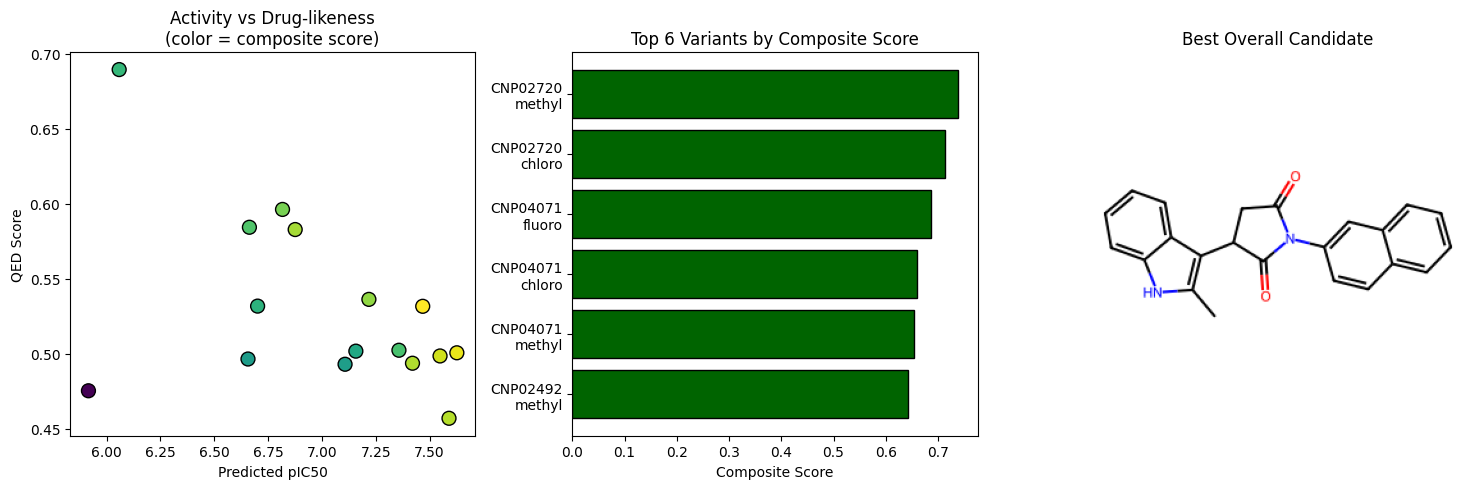

In [10]:
# Block 10: Visualize results

from rdkit.Chem import Draw

print("="*60)
print("VISUALIZING THE OPTIMIZATION RESULTS")
print("="*60)

best_overall = df_final_ranked.iloc[0]
print(f"Best overall candidate (by composite score):")
print(f"  Parent lead: {best_overall['Parent_Lead']}")
print(f"  Modification: {best_overall['Modification']}")
print(f"  Predicted pIC50: {best_overall['Predicted_pIC50']:.2f}")
print(f"  QED Score: {best_overall['QED_Score']:.3f}")
print(f"  SA Score: {best_overall['SA_Score']:.2f}")
print(f"  Composite Score: {best_overall['Composite_Score']:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(df_final_ranked['Predicted_pIC50'], df_final_ranked['QED_Score'],
                c=df_final_ranked['Composite_Score'], cmap='viridis', s=100,
                edgecolor='black')
axes[0].set_xlabel('Predicted pIC50')
axes[0].set_ylabel('QED Score')
axes[0].set_title('Activity vs Drug-likeness\n(color = composite score)')

top6_labels = [f"{r['Parent_Lead'][:8]}\n{r['Modification']}"
               for _, r in df_final_ranked.head(6).iterrows()]
axes[1].barh(top6_labels[::-1], df_final_ranked['Composite_Score'].head(6)[::-1],
             color='darkgreen', edgecolor='black')
axes[1].set_xlabel('Composite Score')
axes[1].set_title('Top 6 Variants by Composite Score')

best_mol = Chem.MolFromSmiles(best_overall['SMILES'])
axes[2].imshow(Draw.MolToImage(best_mol, size=(300,300)))
axes[2].set_title('Best Overall Candidate')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Meaning of Block 10:

Purpose: Provide a complete visual summary of the multi-criteria optimization results, showing the trade-off landscape between activity and drug-likeness, the top-ranked variants, and the structure of the single best overall candidate.

What comes OUT: A three-panel visualization consolidating the entire case study's final result.

In [11]:
# Block 11: DEPLOYMENT BLOCK
# Run the complete multi-criteria discovery pipeline on any compound

print("="*70)
print("INTEGRATED MULTI-CRITERIA DISCOVERY PIPELINE TOOL")
print("="*70)
print("""
********************************************************************
*   The value below is a DEMONSTRATION VALUE ONLY.                 *
*   TO RUN THIS PIPELINE ON YOUR OWN STARTING COMPOUND:            *
*   1. Scroll to "STUDENT INPUT SECTION" below                     *
*   2. REPLACE new_compound_name and new_compound_smiles           *
*   3. Do NOT change anything below "END OF INPUT SECTION"         *
*   4. Then run this cell again                                    *
*   REQUIREMENT: Blocks 1-5 must already have run in this session, *
*   since this tool reuses the trained QSAR model from Block 5.    *
********************************************************************
""")

# ============================================================
# STUDENT INPUT SECTION - EDIT EVERYTHING BELOW THIS LINE
# ============================================================

new_compound_name = "My_Test_Compound"          # <-- EDIT: type your compound's name

new_compound_smiles = "COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O"
# <-- EDIT: replace with YOUR compound's SMILES (demo value is Curcumin)

# ============================================================
# END OF INPUT SECTION - DO NOT EDIT ANYTHING BELOW THIS LINE
# ============================================================

print(f"\nCompound name entered: {new_compound_name}")
if new_compound_name == "My_Test_Compound":
    print("*** WARNING: Still using DEMONSTRATION value. ***")

mol_check = Chem.MolFromSmiles(new_compound_smiles)

if mol_check is None:
    print("\nERROR: Invalid SMILES.")
else:
    print(f"\nStep 1: Scoring the starting compound on all 3 criteria...")

    base_desc = calculate_descriptors(new_compound_smiles)
    base_fp = get_fingerprint(new_compound_smiles)
    base_features = np.hstack(
        [[base_desc[c] for c in desc_cols], base_fp]
    ).reshape(1, -1)

    base_pIC50 = qsar_model.predict(base_features)[0]
    base_qed = QED.qed(mol_check)
    base_sa = sascorer.calculateScore(mol_check)

    print(f"Baseline Predicted pIC50: {base_pIC50:.2f}")
    print(f"Baseline QED Score: {base_qed:.3f}")
    print(f"Baseline SA Score: {base_sa:.2f}")

    print(f"\nStep 2: Generating 4 single-atom analogs...")

    aromatic_atoms = [
        a.GetIdx() for a in mol_check.GetAtoms()
        if a.GetIsAromatic() and a.GetTotalNumHs() > 0
    ]

    deployment_results = [{
        'Variant': 'Original (unmodified)',
        'SMILES': new_compound_smiles,
        'Predicted_pIC50': base_pIC50,
        'QED_Score': base_qed,
        'SA_Score': base_sa
    }]

    if aromatic_atoms:
        target_idx = aromatic_atoms[0]
        for sub_name, atom_symbol in single_atom_subs.items():
            try:
                mol_copy = Chem.MolFromSmiles(new_compound_smiles)
                editable = Chem.RWMol(mol_copy)
                new_idx = editable.AddAtom(Chem.Atom(atom_symbol))
                editable.AddBond(target_idx, new_idx, Chem.BondType.SINGLE)
                new_mol = editable.GetMol()
                Chem.SanitizeMol(new_mol)
                new_smi = Chem.MolToSmiles(new_mol)

                new_desc = calculate_descriptors(new_smi)
                new_fp = get_fingerprint(new_smi)
                new_feat = np.hstack(
                    [[new_desc[c] for c in desc_cols], new_fp]
                ).reshape(1, -1)

                new_pIC50 = qsar_model.predict(new_feat)[0]
                new_qed = QED.qed(new_mol)
                new_sa = sascorer.calculateScore(new_mol)

                deployment_results.append({
                    'Variant': sub_name,
                    'SMILES': new_smi,
                    'Predicted_pIC50': new_pIC50,
                    'QED_Score': new_qed,
                    'SA_Score': new_sa
                })
            except:
                continue
    else:
        print("No available aromatic position found for modification.")

    df_deploy = pd.DataFrame(deployment_results)

    print(f"\nStep 3: Computing composite ranking (same weighting as main pipeline)...")

    df_deploy['Norm_Activity'] = normalize(df_deploy['Predicted_pIC50'], higher_is_better=True)
    df_deploy['Norm_DrugLikeness'] = normalize(df_deploy['QED_Score'], higher_is_better=True)
    df_deploy['Norm_Synthesizability'] = normalize(df_deploy['SA_Score'], higher_is_better=False)

    df_deploy['Composite_Score'] = (
        0.5 * df_deploy['Norm_Activity'] +
        0.3 * df_deploy['Norm_DrugLikeness'] +
        0.2 * df_deploy['Norm_Synthesizability']
    )

    df_deploy_ranked = df_deploy.sort_values(
        'Composite_Score', ascending=False
    ).reset_index(drop=True)

    print(f"\n{'='*70}")
    print(f"PIPELINE RESULTS: {new_compound_name}")
    print(f"{'='*70}")
    print(df_deploy_ranked[['Variant', 'Predicted_pIC50', 'QED_Score',
                              'SA_Score', 'Composite_Score']].to_string(index=False))

    best = df_deploy_ranked.iloc[0]
    print(f"\nBest overall variant: {best['Variant']}")
    print(f"Composite Score: {best['Composite_Score']:.3f}")

    print(f"\nREMINDER: All predictions are computational estimates based")
    print(f"on the training data available to this model. Experimental")
    print(f"validation is required to confirm any result.")

INTEGRATED MULTI-CRITERIA DISCOVERY PIPELINE TOOL

********************************************************************
*   The value below is a DEMONSTRATION VALUE ONLY.                 *
*   TO RUN THIS PIPELINE ON YOUR OWN STARTING COMPOUND:            *
*   1. Scroll to "STUDENT INPUT SECTION" below                     *
*   2. REPLACE new_compound_name and new_compound_smiles           *
*   3. Do NOT change anything below "END OF INPUT SECTION"         *
*   4. Then run this cell again                                    *
*   REQUIREMENT: Blocks 1-5 must already have run in this session, *
*   since this tool reuses the trained QSAR model from Block 5.    *
********************************************************************


Compound name entered: My_Test_Compound
*** WARNING: Still using DEMONSTRATION value. ***

Step 1: Scoring the starting compound on all 3 criteria...
Baseline Predicted pIC50: 5.12
Baseline QED Score: 0.548
Baseline SA Score: 2.43

Step 2: Generating 4 sing